In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/full_churn_dataset.csv")

In [3]:
# Display the first few rows of the dataset
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0


In [4]:
# Dataset description
print(f"Dataset shape: {df.shape}\nRows: {df.shape[0]}\nColumns: {df.shape[1]}\n")
print("Dataset info:")
df.info()

Dataset shape: (505207, 12)
Rows: 505207
Columns: 12

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), str(3)
memory usage: 46.3 MB


In [8]:
# Checking for missing values
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [14]:
# Check for duplicate values
duplicated = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicated}")

Number of duplicate rows: 0


In [ ]:
# Checking the distribution of the target variable
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percentages
})
churn_summary

,Count,Percentage
Churn,,
1.0,280492,55.520322
0.0,224714,44.479678


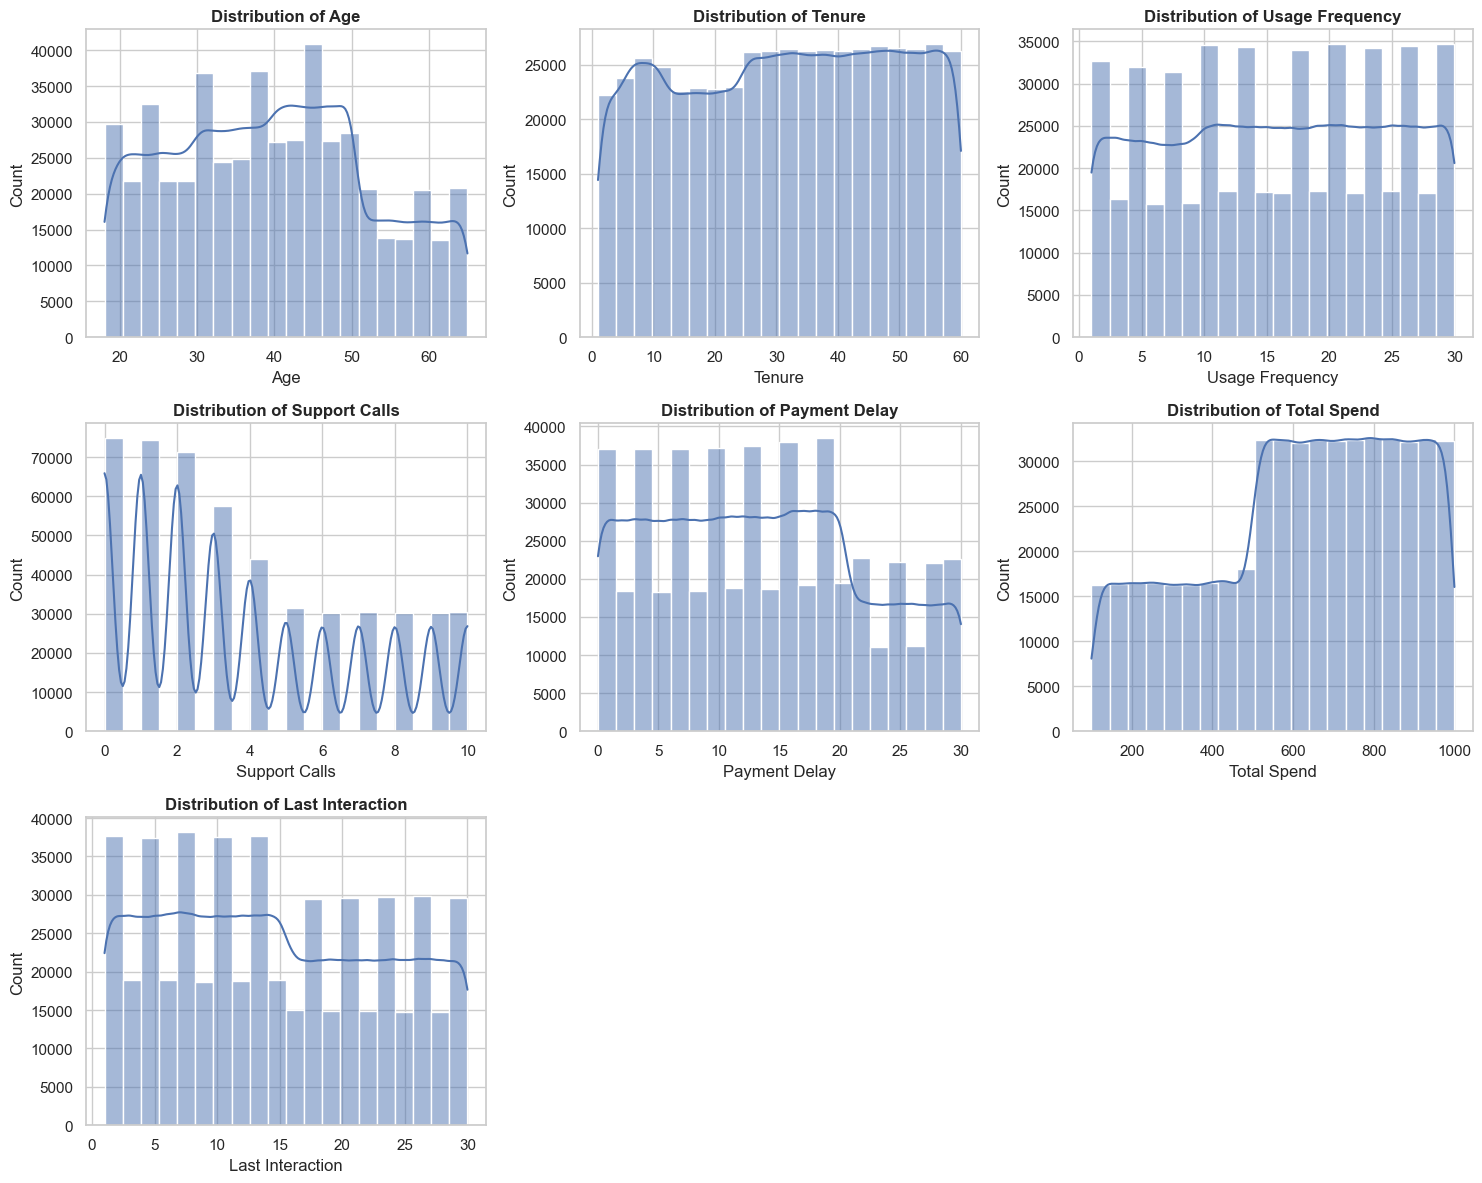

In [21]:
num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction',
]

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i],
        color='#4C72B0',
        bins=20,
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove extra blank subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

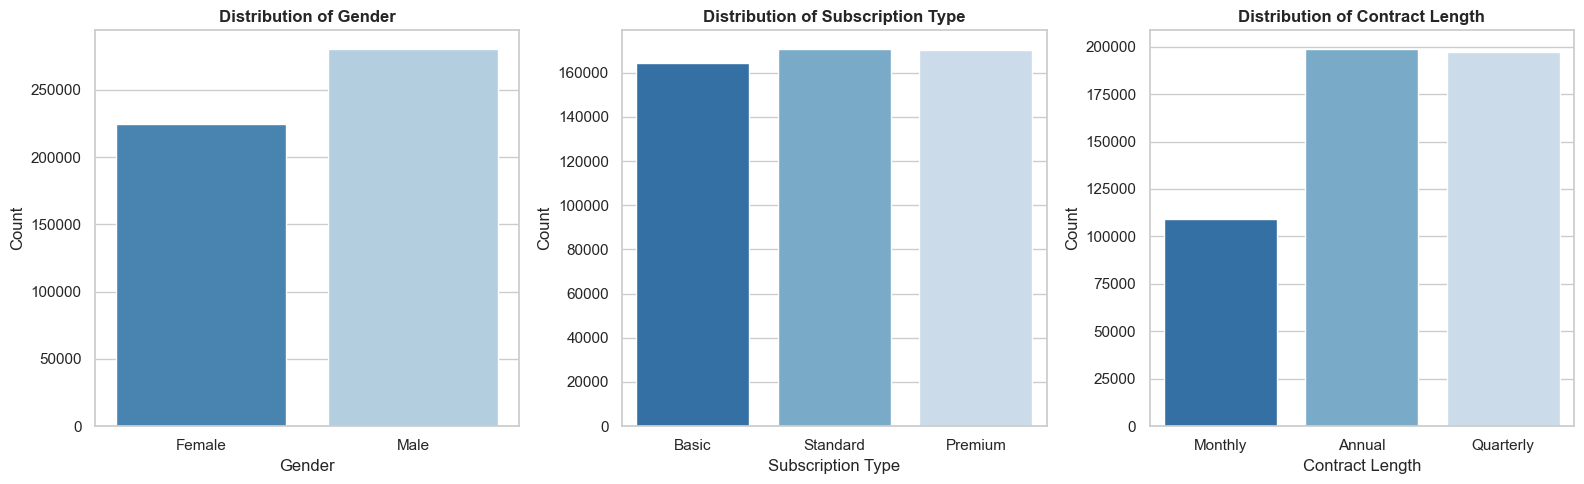

In [22]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(
        x=col,
        data=df,
        ax=axes[i],
        palette='Blues_r',
        hue=col,
        legend=False,
    )
    axes[i].set_title(
        f'Distribution of {col}', fontsize=12, fontweight='bold'
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

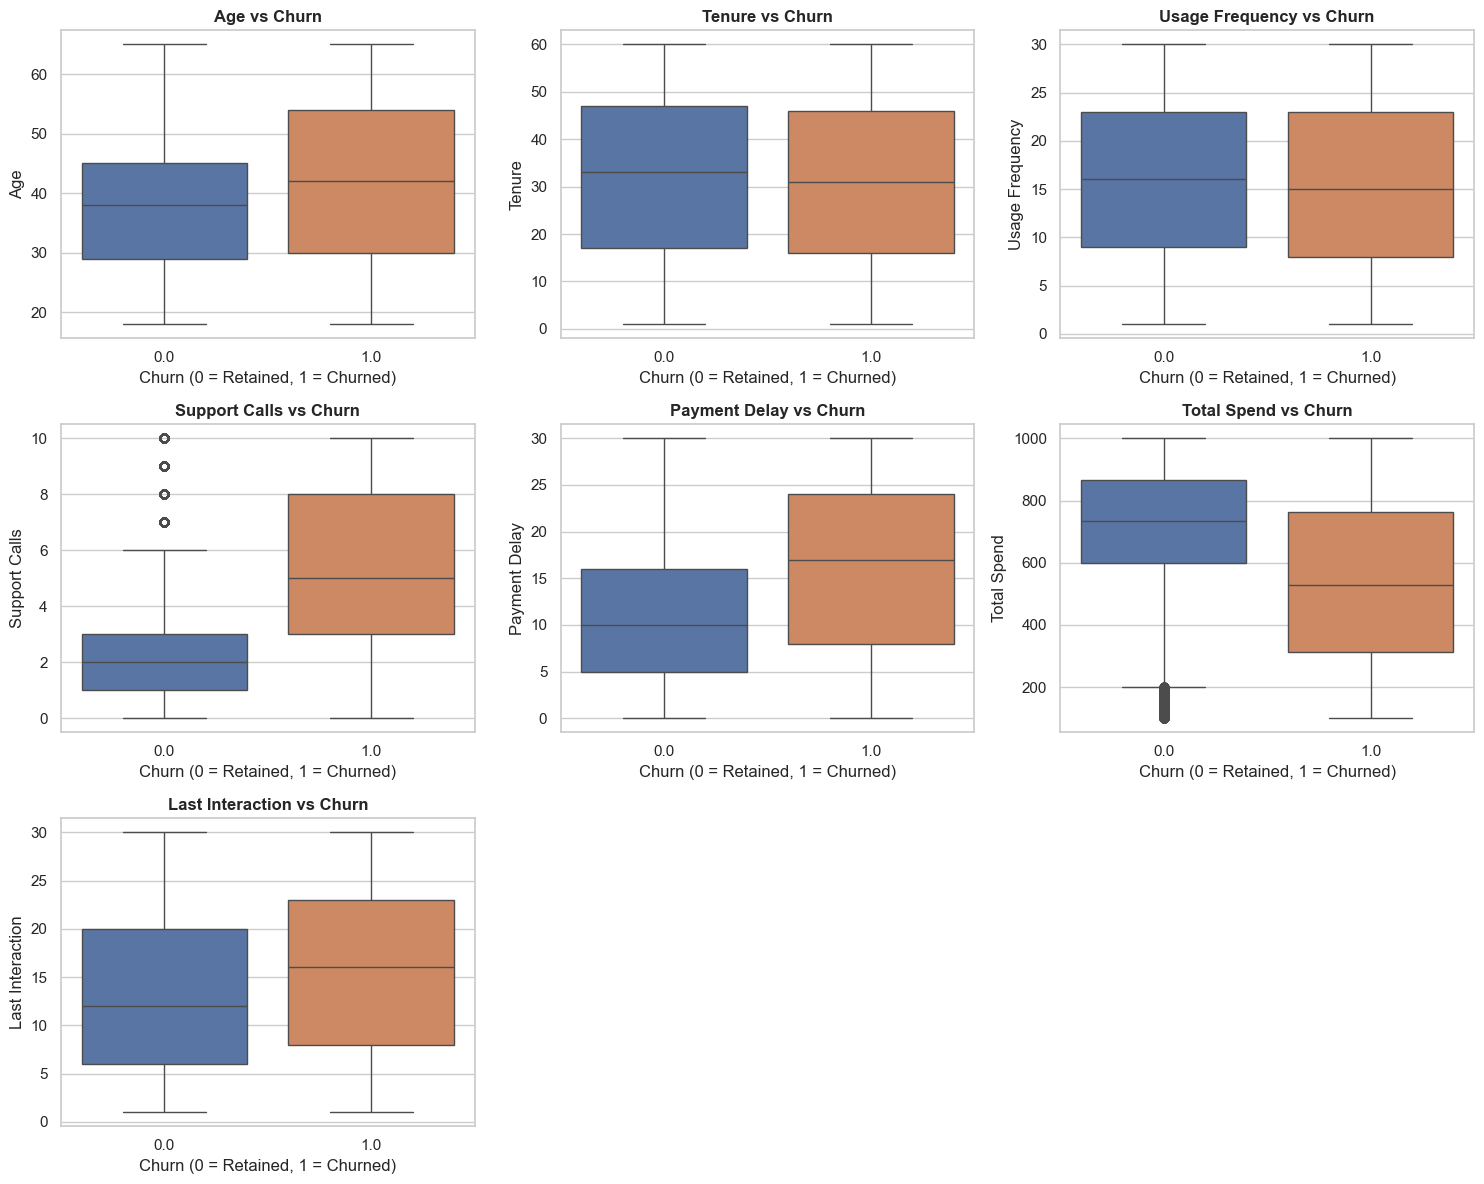

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical features (excluding CustomerID and Churn)
num_cols = ['Age','Tenure','Usage Frequency','Support Calls',
            'Payment Delay','Total Spend','Last Interaction',]

# Set plot style
sns.set_theme(style='whitegrid')

# Grid layout for subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Generate Box Plots
for i, col in enumerate(num_cols):
    sns.boxplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        palette=['#4C72B0', '#DD8452'],
        hue='Churn',
        legend=False,
    )
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn (0 = Retained, 1 = Churned)')
    axes[i].set_ylabel(col)

# Hide any empty subplots in the grid
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

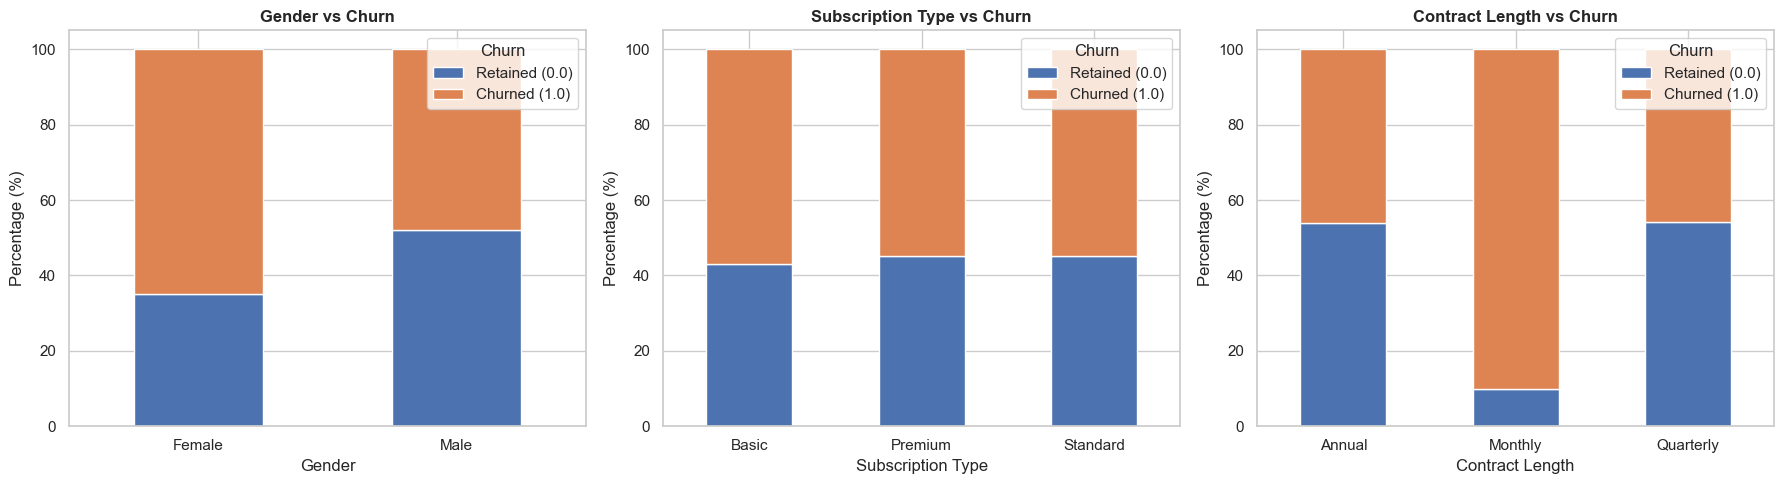

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

# Set up the subplot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    # Calculate percentage proportions for each category
    cross_tab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # Plot 100% stacked bar chart
    cross_tab.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=['#4C72B0', '#DD8452'],
        width=0.5,
    )

    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(['Retained (0.0)', 'Churned (1.0)'], title='Churn')

plt.tight_layout()
plt.show()